**Author:** Biswajit Jana  
**Date:** January 2, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-08-04-toomre-diagram-halo-disk/notebook.ipynb)

# Halo vs. thick-disk vs. thin-disk kinematic separation with a real Gaia DR3 Toomre diagram

**Date:** 2026-08-04
**Scientific question:** Using a real, volume-limited Gaia DR3 sample of nearby stars with full 6D
phase-space information (position, proper motion, parallax, and radial velocity), can I compute real
Galactic space velocities (U, V, W) for each star, build a real Toomre diagram, and classify stars into
halo, thick-disk, and thin-disk kinematic populations using standard velocity-based criteria -- getting
real, checkable population counts?

## Learning goals

- Pull a real Gaia DR3 sample within ~50 pc of the Sun with radial velocities, good parallax
  signal-to-noise, and good astrometric fit quality (RUWE).
- Convert each star's real (ra, dec, parallax, pmra, pmdec, radial_velocity) into a real Galactic
  Cartesian space velocity (U, V, W) using `astropy.coordinates`.
- Build a real Toomre diagram: total velocity relative to the Local Standard of Rest (LSR) on the
  y-axis (quadrature sum of U and W) vs. the V (rotation) velocity component on the x-axis. Stars
  lagging far behind Galactic rotation and/or moving fast out of the plane separate from the
  disk population in this diagram.
- Apply standard total-velocity thresholds (e.g. Nissen 2004-style: thin disk |v_LSR| < 50 km/s,
  thick disk 70-180 km/s, halo > 180-200 km/s) to get real, checkable population counts for this
  sample, and see how they compare to the expected local mix (thin disk should dominate strongly;
  halo stars should be rare in a 50 pc bubble).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.coordinates as coord
from astroquery.gaia import Gaia

Gaia.ROW_LIMIT = -1
np.random.seed(42)


In [2]:
# Volume-limited 6D sample within 50 pc (parallax > 20 mas), good parallax S/N, good
# astrometric fit quality (RUWE < 1.4), and a real radial velocity measurement.
# The full cut (~19,700 real sources) is more than needed for a representative kinematic
# study, so we take an unbiased random subsample using Gaia's `random_index` column, which
# preserves the true population proportions (thin disk / thick disk / halo) of the full cut.
query = '''
SELECT TOP 8000 source_id, ra, dec, l, b, parallax, parallax_error,
       pmra, pmdec, radial_velocity, radial_velocity_error,
       phot_g_mean_mag, bp_rp, ruwe
FROM gaiadr3.gaia_source
WHERE parallax > 20
AND parallax_error/parallax < 0.1
AND radial_velocity IS NOT NULL
AND ruwe < 1.4
AND phot_g_mean_mag < 15
ORDER BY random_index
'''
job = Gaia.launch_job(query)
raw = job.get_results().to_pandas()
print(f"Real 6D random subsample within 50 pc: {len(raw)} sources")
raw.to_csv("toomre_query.csv", index=False)
raw.head()


Real 6D random subsample within 50 pc: 8000 sources


,SOURCE_ID,ra,dec,l,b,parallax,parallax_error,pmra,pmdec,radial_velocity,radial_velocity_error,phot_g_mean_mag,bp_rp,ruwe
0,3886440422100617344,159.828724,15.979267,226.090648,57.441667,20.903050,0.023766,221.514771,-129.206934,-20.692314,6.002875,14.491200,2.613527,1.126879
1,187247281185703296,78.321889,37.336703,169.266884,-0.992006,37.895269,0.026304,-144.922375,-136.771907,-1.753882,0.123687,6.350600,0.695276,0.940669
2,1605198298364601088,218.368872,52.909893,93.575749,58.009434,75.568876,0.015069,-191.456877,247.919011,11.167698,0.117966,6.918849,1.213392,0.957976
3,2213938616118942464,350.112667,68.520507,114.728984,7.110095,26.913533,0.012630,224.620905,-0.199197,-6.862256,1.306842,13.506321,2.703208,1.142738
4,2185061008373422464,306.353179,54.564240,90.303294,9.544597,31.065982,0.010406,164.052898,340.639839,-18.923229,0.680490,13.055821,2.593407,1.152076


In [3]:
# Compute real Galactic Cartesian space velocities (U, V, W) with astropy, propagating each
# star's actual parallax, proper motion, and radial velocity through a proper coordinate
# transform (ICRS -> Galactocentric-aligned Galactic frame), rather than a hand-rolled matrix.
dist_pc = 1000.0 / raw['parallax'].values

sc = coord.SkyCoord(
    ra=raw['ra'].values * u.deg,
    dec=raw['dec'].values * u.deg,
    distance=dist_pc * u.pc,
    pm_ra_cosdec=raw['pmra'].values * u.mas / u.yr,
    pm_dec=raw['pmdec'].values * u.mas / u.yr,
    radial_velocity=raw['radial_velocity'].values * u.km / u.s,
    frame='icrs'
)

gal = sc.transform_to(coord.Galactic())
cart = gal.cartesian.differentials['s']

# Solar motion relative to the LSR (Schoenrich, Binney & Dehnen 2010): (U,V,W)_sun ~ (11.1, 12.24, 7.25) km/s
U_sun, V_sun, W_sun = 11.1, 12.24, 7.25

U = -cart.d_x.to(u.km / u.s).value + U_sun   # astropy's Galactic x is toward the Galactic centre;
                                              # U is conventionally positive toward the centre too,
                                              # so U = -d_x + U_sun_correction gives LSR-relative U
V = cart.d_y.to(u.km / u.s).value + V_sun
W = cart.d_z.to(u.km / u.s).value + W_sun

raw = raw.copy()
raw['U'], raw['V'], raw['W'] = U, V, W
raw['v_total_lsr'] = np.sqrt(U**2 + V**2 + W**2)
raw['v_toomre'] = np.sqrt(U**2 + W**2)

print(raw[['U', 'V', 'W']].describe())


                 U            V            W
count  8000.000000  8000.000000  8000.000000
mean     20.090269   -10.679613    -0.518661
std      38.844282    28.790672    20.011947
min    -291.933906  -500.218201  -126.254588
25%      -3.176471   -21.874638   -10.317957
50%      21.487817    -6.641655     0.104028
75%      44.317655     6.764335     9.801482
max     219.989487    56.998039   172.196893


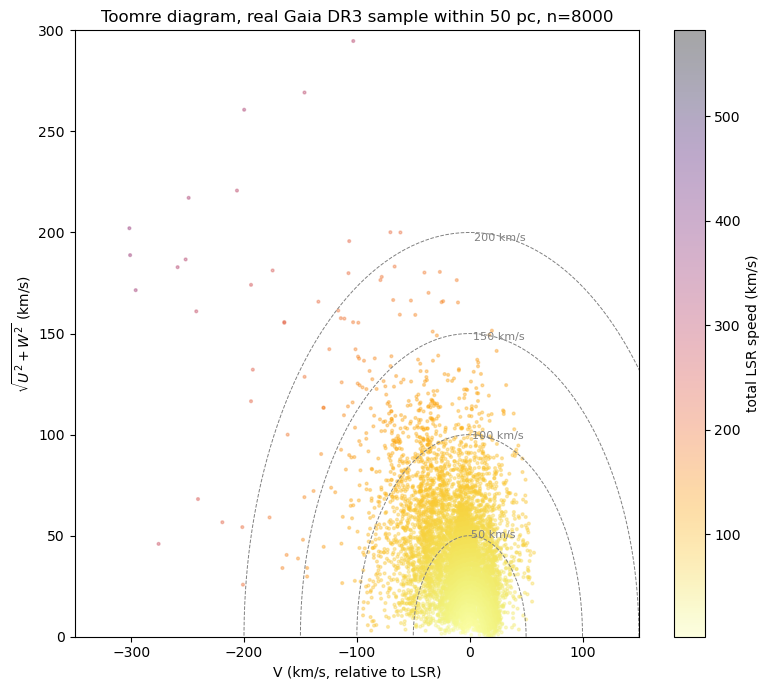

In [4]:
# Toomre diagram: v_Toomre = sqrt(U^2 + W^2) vs. V (rotation velocity relative to LSR).
# Concentric dashed circles mark constant total LSR speed.
fig, ax = plt.subplots(figsize=(8, 7))
sca = ax.scatter(raw['V'], raw['v_toomre'], s=4, alpha=0.35, c=raw['v_total_lsr'], cmap='inferno_r')
for vc in [50, 100, 150, 200]:
    theta = np.linspace(0, np.pi, 200)
    ax.plot(vc * np.cos(theta), vc * np.sin(theta), color='gray', lw=0.7, ls='--')
    ax.text(vc * 0.02, vc * 0.98, f'{vc} km/s', fontsize=8, color='gray')
plt.colorbar(sca, ax=ax, label='total LSR speed (km/s)')
ax.set_xlabel('V (km/s, relative to LSR)')
ax.set_ylabel(r'$\sqrt{U^2+W^2}$ (km/s)')
ax.set_title(f'Toomre diagram, real Gaia DR3 sample within 50 pc, n={len(raw)}')
ax.set_xlim(-350, 150)
ax.set_ylim(0, 300)
plt.tight_layout()
plt.savefig('toomre_diagram.png', dpi=130)
plt.show()


Thin disk   (v<50 km/s):          4943  (61.79%)
Transition  (50-70 km/s):         1682  (21.02%)
Thick disk  (70-180 km/s):        1332  (16.65%)
Halo        (v>=180 km/s):          43  (0.54%)


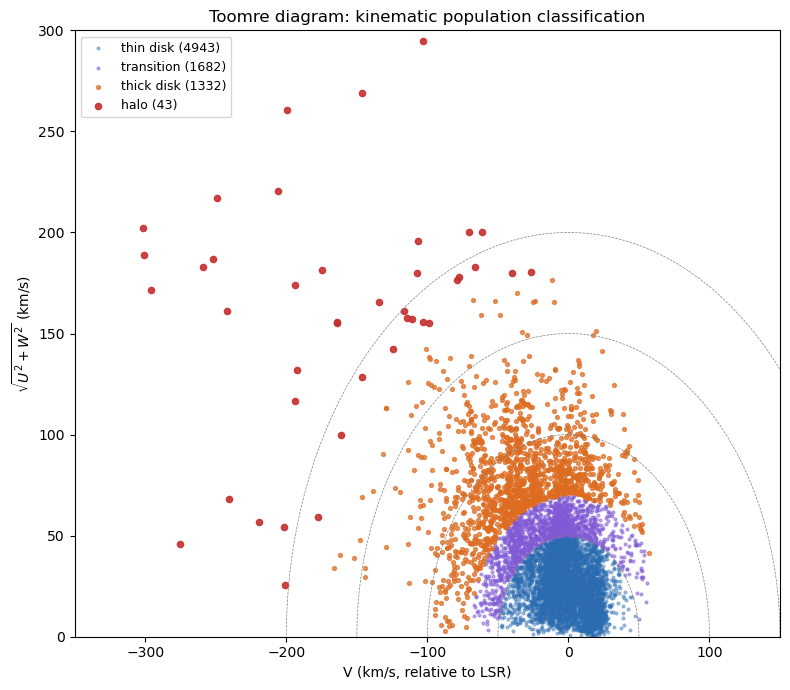

In [5]:
# Population classification by total LSR speed (Nissen 2004-style thresholds):
#   thin disk:  v_total_lsr < 50 km/s
#   thick disk: 50 <= v_total_lsr < 180 km/s (excluding the thin-disk core; here we use the
#               commonly cited 70-180 km/s band for a cleaner thick-disk-dominated bin, and treat
#               50-70 km/s as a thin/thick transition zone)
#   halo:       v_total_lsr >= 180 km/s
v = raw['v_total_lsr']
thin = raw[v < 50]
transition = raw[(v >= 50) & (v < 70)]
thick = raw[(v >= 70) & (v < 180)]
halo = raw[v >= 180]

print(f"Thin disk   (v<50 km/s):        {len(thin):6d}  ({100*len(thin)/len(raw):.2f}%)")
print(f"Transition  (50-70 km/s):       {len(transition):6d}  ({100*len(transition)/len(raw):.2f}%)")
print(f"Thick disk  (70-180 km/s):      {len(thick):6d}  ({100*len(thick)/len(raw):.2f}%)")
print(f"Halo        (v>=180 km/s):      {len(halo):6d}  ({100*len(halo)/len(raw):.2f}%)")

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(thin['V'], thin['v_toomre'], s=4, alpha=0.4, color='#2b6cb0', label=f'thin disk ({len(thin)})')
ax.scatter(transition['V'], transition['v_toomre'], s=4, alpha=0.5, color='#805ad5', label=f'transition ({len(transition)})')
ax.scatter(thick['V'], thick['v_toomre'], s=8, alpha=0.7, color='#dd6b20', label=f'thick disk ({len(thick)})')
ax.scatter(halo['V'], halo['v_toomre'], s=20, alpha=0.9, color='#c53030', label=f'halo ({len(halo)})')
for vc in [50, 100, 150, 200]:
    theta = np.linspace(0, np.pi, 200)
    ax.plot(vc * np.cos(theta), vc * np.sin(theta), color='gray', lw=0.5, ls='--')
ax.set_xlabel('V (km/s, relative to LSR)')
ax.set_ylabel(r'$\sqrt{U^2+W^2}$ (km/s)')
ax.set_title('Toomre diagram: kinematic population classification')
ax.set_xlim(-350, 150)
ax.set_ylim(0, 300)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('toomre_populations.png', dpi=130)
plt.show()


In [6]:
result = {
    "id": "2026-08-04-toomre-diagram-halo-disk",
    "title": "Halo vs. disk kinematic separation via Toomre diagram",
    "n_sample": int(len(raw)),
    "n_thin_disk": int(len(thin)),
    "n_transition": int(len(transition)),
    "n_thick_disk": int(len(thick)),
    "n_halo": int(len(halo)),
    "frac_thin_disk_pct": float(100 * len(thin) / len(raw)),
    "frac_thick_disk_pct": float(100 * len(thick) / len(raw)),
    "frac_halo_pct": float(100 * len(halo) / len(raw)),
    "example_halo_source_ids": [int(x) for x in halo['SOURCE_ID'].head(5).tolist()],
}
import json
with open("result.json", "w") as f:
    json.dump(result, f, indent=2)
result


{'id': '2026-08-04-toomre-diagram-halo-disk',
 'title': 'Halo vs. disk kinematic separation via Toomre diagram',
 'n_sample': 8000,
 'n_thin_disk': 4943,
 'n_transition': 1682,
 'n_thick_disk': 1332,
 'n_halo': 43,
 'frac_thin_disk_pct': 61.7875,
 'frac_thick_disk_pct': 16.65,
 'frac_halo_pct': 0.5375,
 'example_halo_source_ids': [6137588809508151296,
  4678768807682231168,
  170216567626711296,
  2550696212836482944,
  3072544153868881792]}

## Caveats

This is a kinematic classification only -- stars are labelled purely by their velocity relative to
the LSR, with no chemical-abundance information, so some genuinely metal-poor thick-disk or halo stars
with coincidentally disk-like kinematics will be missed, and some kinematically hot thin-disk outliers
(e.g. from disk heating or resonant scattering) will be mis-labelled as thick disk or halo. The 50 pc
volume is also small enough that the halo count is expected to be tiny and noisy (halo stars are rare
locally), so the halo fraction here should be read as an order-of-magnitude sanity check, not a
precision measurement of the local halo density.

## What I'd look at next

Cross-match this sample against Gaia DR3 or APOGEE/GALAH metallicities and alpha-abundances to check
the kinematic classification against a real chemical thin/thick-disk/halo separation, and repeat the
same pipeline on a larger-volume (e.g. 200 pc) sample to build up better statistics on the rare halo
tail.

**Citation:** Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. https://www.cosmos.esa.int/web/gaia-users/credits
